In [1]:
!pip install scikit-learn seaborn matplotlib pandas

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Load data
df = pd.read_csv('/Users/alphievarghese/Downloads/Mall_Customers.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (200, 5)

First 5 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
# Basic info
print("Dataset Info:")
print(df.info())
print("\nMissing values:", df.isnull().sum().sum())
print("\nStatistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Missing values: 0

Statistics:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


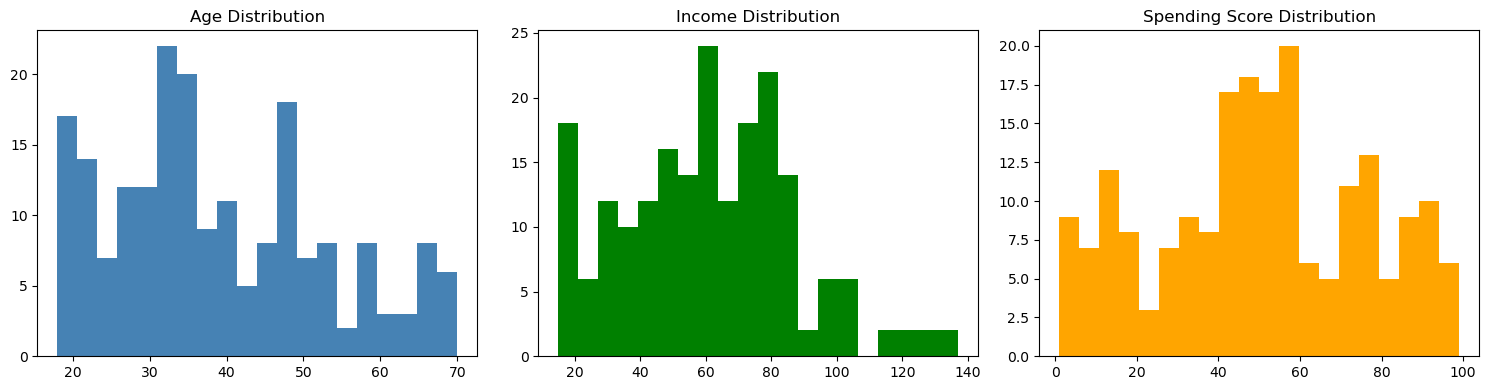

EDA complete!


In [5]:
# Visualize distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['Age'], bins=20, color='steelblue')
axes[0].set_title('Age Distribution')

axes[1].hist(df['Annual Income (k$)'], bins=20, color='green')
axes[1].set_title('Income Distribution')

axes[2].hist(df['Spending Score (1-100)'], bins=20, color='orange')
axes[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.savefig('/Users/alphievarghese/Downloads/distributions.png')
plt.show()
print("EDA complete!")

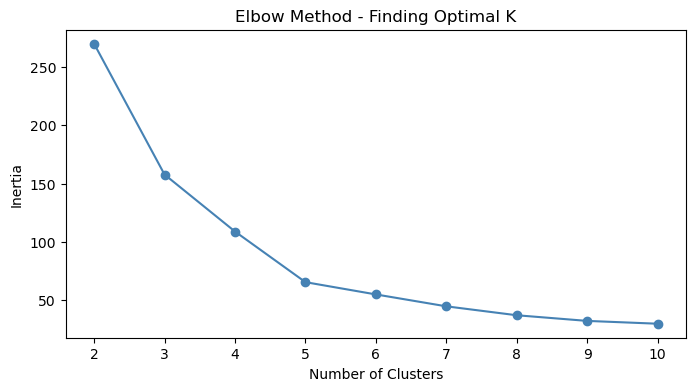

Best K is where the curve bends!


In [6]:
# Select features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find best number of clusters using Elbow method
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', color='steelblue')
plt.title('Elbow Method - Finding Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.savefig('/Users/alphievarghese/Downloads/elbow_curve.png')
plt.show()
print("Best K is where the curve bends!")

In [7]:
# Apply K-Means with k=5 (typical best for this dataset)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Silhouette score - measures cluster quality
score = silhouette_score(X_scaled, df['Cluster'])
print(f"Silhouette Score: {score:.3f} (closer to 1 = better)")

# Cluster summary
print("\nCustomers per cluster:")
print(df['Cluster'].value_counts())

Silhouette Score: 0.555 (closer to 1 = better)

Customers per cluster:
Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


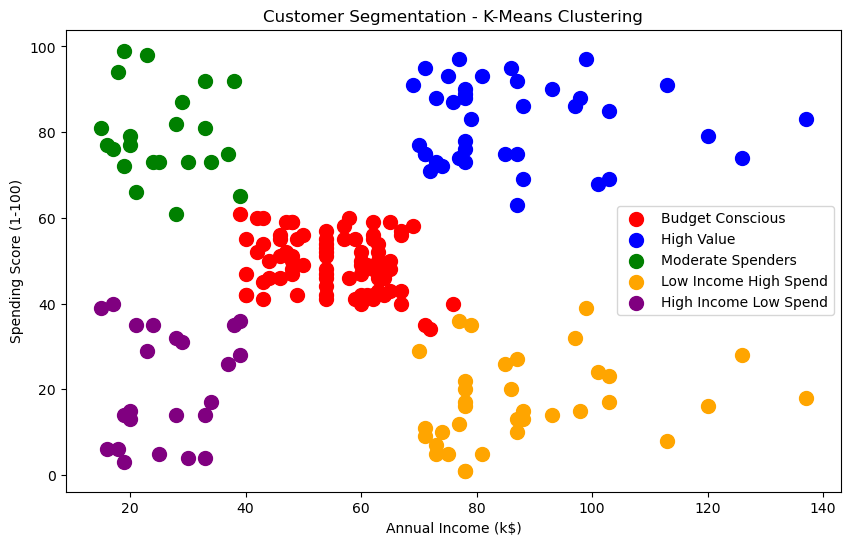

Segmentation complete!


In [8]:
# Color map for clusters
colors = ['red', 'blue', 'green', 'orange', 'purple']
cluster_names = ['Budget Conscious', 'High Value', 
                 'Moderate Spenders', 'Low Income High Spend', 
                 'High Income Low Spend']

plt.figure(figsize=(10, 6))
for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['Annual Income (k$)'],
                cluster_data['Spending Score (1-100)'],
                c=colors[i], label=cluster_names[i], s=100)

plt.title('Customer Segmentation - K-Means Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.savefig('/Users/alphievarghese/Downloads/customer_segments.png')
plt.show()
print("Segmentation complete!")

In [9]:
# Summary per segment
summary = df.groupby('Cluster').agg({
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'Age': 'mean',
    'CustomerID': 'count'
}).round(1)

summary.columns = ['Avg Income', 'Avg Spending', 'Avg Age', 'Total Customers']
summary.index = cluster_names
print("\nBusiness Insights by Segment:")
print(summary)

# Save to Excel
summary.to_excel('/Users/alphievarghese/Downloads/segmentation_report.xlsx')
print("\nReport saved!")


Business Insights by Segment:
                       Avg Income  Avg Spending  Avg Age  Total Customers
Budget Conscious             55.3          49.5     42.7               81
High Value                   86.5          82.1     32.7               39
Moderate Spenders            25.7          79.4     25.3               22
Low Income High Spend        88.2          17.1     41.1               35
High Income Low Spend        26.3          20.9     45.2               23

Report saved!
